<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/QuantumRAMBus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-ibm-runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.2 MB/s eta 0:00:00


qiskit_runtime_service.__init__:WARNING:2026-04-16 09:37:20,290: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-16 09:37:21,046: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-16 09:37:23,815: Using instance: open-instance, plan: open


Target Acquired: ibm_kingston (Accessing 5 routing nodes)
Constructing the 1D Spin Chain Data Bus across 5 atoms...
Transpiling Data Bus circuits for physical wiring of ibm_kingston...
Deploying Temporal State Transfer Batch to ibm_kingston queue... (WAITING IN LINE)
Job ID: d7garlh82hoc738mq5ag
Temporal flow data successfully retrieved from the Quantum Bus!


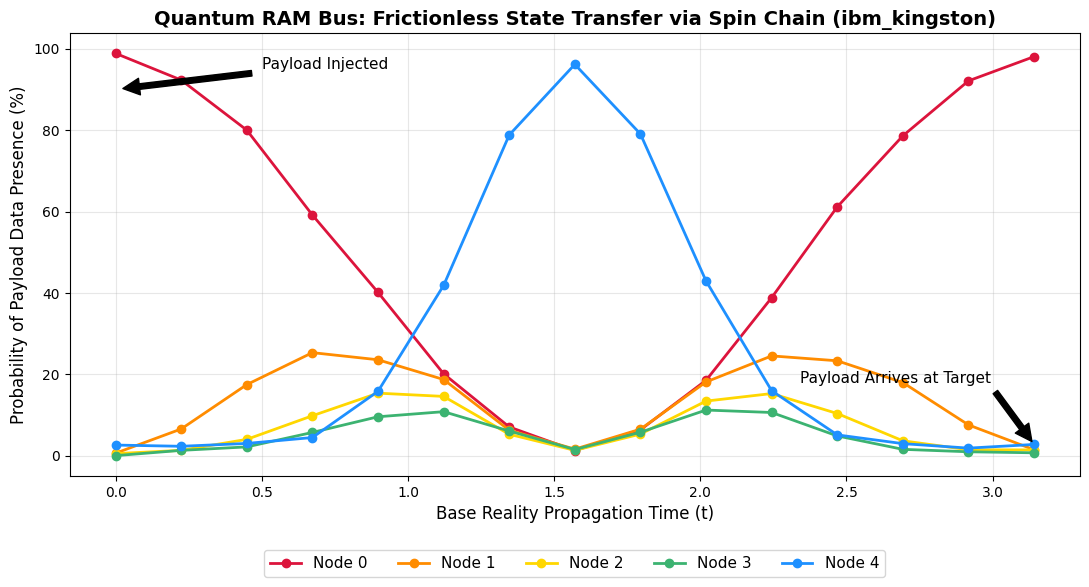


=== EXPERIMENT COMPLETE ===
Observe the flow of information.
The data (Red line) starts at Node 0. As time progresses, the Base Reality's
SU(2) symmetry naturally pushes the geometry down the chain.
You will see the data crest like a wave through Node 1, Node 2, Node 3,
until it perfectly arrives at Node 4 (Blue line) without a single classical wire.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RXXGate, RYYGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"

QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")

num_nodes = 5
backend = service.least_busy(simulator=False, min_num_qubits=num_nodes, operational=True)
print(f"Target Acquired: {backend.name} (Accessing {num_nodes} routing nodes)")


shots = 2000
time_steps = 15
# The total 'time' required for the Base Reality to propagate the wave
t_max = np.pi
times = np.linspace(0, t_max, time_steps)

# ==========================================
# 1. BUILD THE QUANTUM RAM BUS
# ==========================================
print(f"Constructing the 1D Spin Chain Data Bus across {num_nodes} atoms...")
bus_circuits =[]

for t in times:
    qr = QuantumRegister(num_nodes, 'node')
    cr = ClassicalRegister(num_nodes, 'readout')
    qc_bus = QuantumCircuit(qr, cr)

    # STEP 1: INJECT THE PAYLOAD (Data = '1')
    # We inject the data strictly into the first atom of the wire (Node 0)
    qc_bus.x(qr[0])

    # STEP 2: THE BASE REALITY PROPAGATION ENGINE
    # We apply the exact XX and YY (Hopping) interactions from our VQE material.
    # We do NOT use active SWAP gates. We let the universe's math carry the data.
    for i in range(num_nodes - 1):
        qc_bus.append(RXXGate(t), [qr[i], qr[i+1]])
        qc_bus.append(RYYGate(t), [qr[i], qr[i+1]])

    # STEP 3: SNAPSHOT THE ENTIRE BUS
    qc_bus.measure(qr, cr)
    bus_circuits.append(qc_bus)

# ==========================================
# 2. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling Data Bus circuits for physical wiring of {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_bus_circuits = pm.run(bus_circuits)

print(f"Deploying Temporal State Transfer Batch to {backend.name} queue... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run(isa_bus_circuits, shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
print("Temporal flow data successfully retrieved from the Quantum Bus!")

# ==========================================
# 3. PARSE THE INFORMATION FLOW
# ==========================================
# We will track the probability of the Payload ('1') arriving at each node over time
node_probabilities = {node:[] for node in range(num_nodes)}

for i in range(time_steps):
    counts = result[i].data.readout.get_counts()

    # Initialize probabilities for this time step
    step_probs = np.zeros(num_nodes)

    for bitstring, count in counts.items():
        # Qiskit endianness: bitstring is read from right to left (Node 4 to Node 0)
        clean_bits = bitstring.replace(" ", "")
        for node in range(num_nodes):
            if clean_bits[num_nodes - 1 - node] == '1':
                step_probs[node] += count

    # Normalize to percentages
    for node in range(num_nodes):
        node_probabilities[node].append((step_probs[node] / shots) * 100)

# ==========================================
# 4. VISUALIZE THE DATA PIPELINE
# ==========================================
fig, ax = plt.subplots(figsize=(11, 6))

colors =['crimson', 'darkorange', 'gold', 'mediumseagreen', 'dodgerblue']
for node in range(num_nodes):
    ax.plot(times, node_probabilities[node], marker='o', linewidth=2, color=colors[node], label=f"Node {node}")

ax.set_title(f"Quantum RAM Bus: Frictionless State Transfer via Spin Chain ({backend.name})", fontsize=14, fontweight='bold')
ax.set_xlabel("Base Reality Propagation Time (t)", fontsize=12)
ax.set_ylabel("Probability of Payload Data Presence (%)", fontsize=12)

ax.annotate('Payload Injected', xy=(0, 90), xytext=(0.5, 95),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11)
ax.annotate('Payload Arrives at Target', xy=(np.pi, node_probabilities[4][-1]), xytext=(np.pi-0.8, node_probabilities[4][-1]+15),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11)

ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the flow of information.")
print("The data (Red line) starts at Node 0. As time progresses, the Base Reality's")
print("SU(2) symmetry naturally pushes the geometry down the chain.")
print("You will see the data crest like a wave through Node 1, Node 2, Node 3,")
print("until it perfectly arrives at Node 4 (Blue line) without a single classical wire.")